# Current Density from Field Line Geometry

Writing $\mathbf{B} = B\,\mathbf{T}$ with $\mathbf{T}$ the unit tangent, the curl of $\mathbf{B}$ closes in the Frenet-Serret frame $(\mathbf{T}, \mathbf{n}, \mathbf{b})$ with no $\mathbf{n}$-component of $\nabla\times\mathbf{T}$:

$$
\mu_0 \mathbf{J} \;=\; \underbrace{B\left[(\partial\mathbf{T}/\partial n)\cdot\mathbf{b} + (\partial\mathbf{n}/\partial b)\cdot\mathbf{T}\right]}_{\text{twist} \;=\; \mu_0 j_\parallel}\,\mathbf{T}
\;+\; \underbrace{\frac{\partial B}{\partial b}}_{\text{magnetic pressure}}\,\mathbf{n}
\;+\; \underbrace{\left[B\kappa - \frac{\partial B}{\partial n}\right]}_{\text{tension} - \text{pressure}}\,\mathbf{b}
$$

The parallel current is **pure field-line twist** ($\mu_0 j_\parallel / B = \mathbf{T}\cdot(\nabla\times\mathbf{T})$, the force-free $\alpha$ where $\mathbf{J}_\perp = 0$): curvature and $|B|$ gradients contribute only to the perpendicular components. The twist term is carried entirely by the frame's directional derivatives (`dT_dn_b + dn_db_T`, notebook 07); this notebook adds the missing scalar pieces — the $|B|$ gradients along the frame — and assembles $\mu_0\mathbf{J}$.

Covered here:

1. `field_magnitude_derivatives` — $\partial B/\partial T$, $\partial B/\partial n$, $\partial B/\partial b$
2. `field_line_current_density` — $\mu_0\mathbf{J}$ on the frame and in GSM, validated against a direct finite-difference $\nabla\times\mathbf{B}$
3. The dipole as a nontrivial test: a current-free field requires $B\kappa = \partial B/\partial n$ exactly
4. `verify_divergence_identity` — $\nabla\cdot\mathbf{B}$ from the same machinery, and what it reveals about T96
5. Maps of the parallel current and twist with `mageometry.viz`
6. Performance and practical notes (choosing $\delta$, frame validity, units)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mageometry import (
    geopack, geopack_field,
    field_magnitude_derivatives, field_line_current_density,
    verify_divergence_identity, field_line_frame_quality,
)

ps = geopack.recalc(100)
parmod = [2.0, -20.0, 0.0, -5.0, 0, 0, 0, 0, 0, 0]   # [Pdyn, Dst, ByIMF, BzIMF, ...]
t96 = geopack_field('t96', 'igrf', parmod, ps)
dip = geopack_field(external=None, internal='dip')

## 1. $|B|$ gradients along the frame

`field_magnitude_derivatives` central-differences $|B|$ along the local tangent, normal, and binormal. `dB_dT` is the mirror-force gradient along the line (defined wherever the tangent is); `dB_dn`/`dB_db` need the base-point frame and are NaN where it is undefined. Units: field-unit per length-unit (nT/Re here).

In [2]:
x = np.array([-6.0, -7.0, 5.0, 3.0])
y = np.array([ 1.0,  2.0, 2.0, -3.0])
z = np.array([ 2.0,  1.5, 1.0,  2.0])

mag = field_magnitude_derivatives(t96, x, y, z, delta=2e-3)
for k, v in mag.items():
    print(f"{k:>6}: {np.array2string(np.asarray(v), precision=4, suppress_small=True)}")

     B: [213.7264 135.6372 200.8095 281.7378]
 dB_dT: [ 86.23    44.9876 -89.9933  82.2693]
 dB_dn: [ 10.9823   3.5499  62.8155 177.0929]
 dB_db: [-0.3184 -0.5003 -0.2915  0.3362]


## 2. Current density, validated against $\nabla\times\mathbf{B}$

`field_line_current_density` returns $\mu_0\mathbf{J}$ projected on the frame (`mu0J_T`, `mu0J_n`, `mu0J_b`), the same vector in the field's Cartesian coordinates (`mu0J_x/y/z`), and the twist `alpha` $= \mu_0 j_\parallel/B$, with $|B|$ and $\kappa$ as by-products. For geopack fields, $J\,[\mathrm{A/m^2}] \approx \mu_0 J\,[\mathrm{nT/Re}] \times 1.25\times10^{-10}$ (0.125 nA/m² per nT/Re).

As an independent reference we take a plain Cartesian central-difference curl:

In [3]:
def curl_fd(field, x, y, z, h=5e-4):
    f = lambda px, py, pz: np.stack(field(px, py, pz))
    dfdx = (f(x + h, y, z) - f(x - h, y, z)) / (2 * h)
    dfdy = (f(x, y + h, z) - f(x, y - h, z)) / (2 * h)
    dfdz = (f(x, y, z + h) - f(x, y, z - h)) / (2 * h)
    return np.stack([dfdy[2] - dfdz[1], dfdz[0] - dfdx[2], dfdx[1] - dfdy[0]])

cur = field_line_current_density(t96, x, y, z, delta=2e-3)
curl = curl_fd(t96, x, y, z)
j_frenet = np.stack([cur['mu0J_x'], cur['mu0J_y'], cur['mu0J_z']])
rel_err = np.sqrt(((j_frenet - curl) ** 2).sum(axis=0)) / np.sqrt((curl ** 2).sum(axis=0))

print("mu0J_T [nT/Re]:", np.round(cur['mu0J_T'], 4))
print("mu0J_n [nT/Re]:", np.round(cur['mu0J_n'], 4))
print("mu0J_b [nT/Re]:", np.round(cur['mu0J_b'], 4))
print("alpha  [1/Re] :", np.round(cur['alpha'], 6))
print("relative error of mu0J vs finite-difference curl:", [f"{e:.1e}" for e in rel_err])

mu0J_T [nT/Re]: [ 0.1617 -0.998   0.1606  0.2994]
mu0J_n [nT/Re]: [-0.3184 -0.5003 -0.2915  0.3362]
mu0J_b [nT/Re]: [-0.1897 -0.6488 15.3731 22.6308]
alpha  [1/Re] : [ 0.000757 -0.007358  0.0008    0.001063]
relative error of mu0J vs finite-difference curl: ['1.7e-05', '3.4e-06', '8.3e-07', '1.0e-05']


The agreement is at the level of the finite-difference truncation error ($\propto\delta^2$). At `delta=2e-3` the median relative error over the 3–9 Re region is $\sim10^{-6}$ of $|\nabla\times\mathbf{B}|$; near surfaces where the model field has discontinuous derivatives (T96's Birkeland-current module) differences with different stencils legitimately disagree at the percent level — screen such regions with `field_line_frame_quality` and a $\delta$-convergence check as in `tests/test_field_line_current.py`.

## 3. The dipole as a cancellation test

A dipole carries no current, but its Frenet decomposition is not trivially zero: the twist vanishes by symmetry, yet the binormal component demands the exact cancellation $B\kappa = \partial B/\partial n$ between the curvature term and the $|B|$ gradient. Checking $\mu_0\mathbf{J} \approx 0$ therefore exercises the frame, the curvature, and the magnitude derivatives together:

In [4]:
r = np.array([4.0, 5.0, 6.0, 7.0, 8.0])
lat = np.deg2rad([25.0, 30.0, -35.0, 40.0, -30.0])
xd, yd, zd = r * np.cos(lat), np.zeros_like(r), r * np.sin(lat)

cd = field_line_current_density(dip, xd, yd, zd, delta=2e-3)
scale = cd['B'] * cd['curvature']          # size of the two cancelling terms
for k in ('mu0J_T', 'mu0J_n', 'mu0J_b'):
    print(f"|{k}| / Bκ  max: {np.nanmax(np.abs(cd[k]) / scale):.2e}")

|mu0J_T| / Bκ  max: 0.00e+00
|mu0J_n| / Bκ  max: 0.00e+00
|mu0J_b| / Bκ  max: 1.45e-06


## 4. $\nabla\cdot\mathbf{B}$ from the frame — and a surprise in T96

$\nabla\cdot\mathbf{B} = \partial B/\partial T + B\,(\mathrm{dT\_dn\_n} + \mathrm{dT\_db\_b})$, assembled by `verify_divergence_identity` from two independent machineries (scalar $|B|$ differences and frame-vector differences). On a solenoidal field it vanishes to truncation accuracy — an end-to-end consistency check. A residual that does **not** shrink with $\delta$ is a property of the field itself, and T96 has one: parts of its Birkeland-current module are genuinely non-solenoidal at the $|\nabla\cdot\mathbf{B}| \sim 1$ nT/Re level (also in the original scalar implementation).

In [5]:
# Solenoidal dipole: residual at truncation level
div_dip = verify_divergence_identity(dip, xd, yd, zd, delta=2e-3)
print("dipole  max |divB| / Bκ :", f"{np.nanmax(np.abs(div_dip) / scale):.2e}")

# T96: delta-independent residual near the Birkeland-current module
pt = (0.0, 4.91, 3.44)   # r ~ 6 Re, dawn sector, mid-latitude
for d in (2e-3, 1e-3, 5e-4):
    dv = verify_divergence_identity(t96, *pt, delta=d)
    print(f"T96+IGRF at {pt}, delta={d:.0e}:  divB = {dv:+.4f} nT/Re")

dipole  max |divB| / Bκ : 2.87e-06


T96+IGRF at (0.0, 4.91, 3.44), delta=2e-03:  divB = +1.3391 nT/Re


T96+IGRF at (0.0, 4.91, 3.44), delta=1e-03:  divB = +1.3391 nT/Re


T96+IGRF at (0.0, 4.91, 3.44), delta=5e-04:  divB = +1.3391 nT/Re


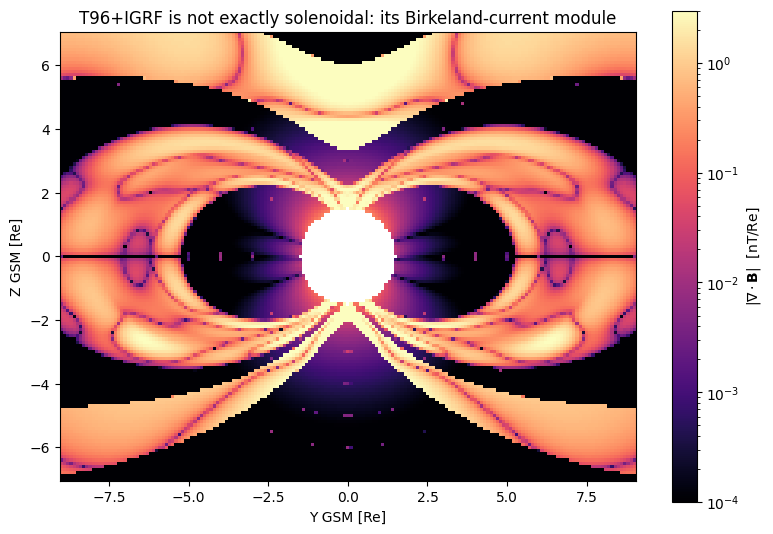

In [6]:
# Where is the model non-solenoidal? |divB| on the x=0 (dawn-dusk) plane.
yy, zz = np.meshgrid(np.linspace(-9, 9, 181), np.linspace(-7, 7, 141))
xx = np.zeros_like(yy)
rr = np.sqrt(yy**2 + zz**2)
inside = (rr > 1.5).ravel()              # skip the near-Earth region (and r=0)
dv = np.full(yy.size, np.nan)
dv[inside] = verify_divergence_identity(t96, xx.ravel()[inside], yy.ravel()[inside],
                                        zz.ravel()[inside], delta=2e-3)
dv = dv.reshape(yy.shape)

fig, ax = plt.subplots(figsize=(8, 5.5))
pc = ax.pcolormesh(yy, zz, np.abs(dv), norm=plt.matplotlib.colors.LogNorm(1e-4, 3),
                   cmap='magma', shading='auto')
fig.colorbar(pc, ax=ax, label=r'$|\nabla\cdot\mathbf{B}|$  [nT/Re]')
ax.set_xlabel('Y GSM [Re]'); ax.set_ylabel('Z GSM [Re]')
ax.set_title('T96+IGRF is not exactly solenoidal: its Birkeland-current module')
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

The bright cones are T96's Region-1/2 field-aligned current module. Any analysis that feeds this region's $\mu_0\mathbf{J}$ into current-continuity arguments (e.g. tracing $j_\parallel/B$ along field lines) should treat this map as a systematic-error floor of the model itself.

## 5. Maps of the parallel current and twist

The current-density components are registered as `viz` quantities (`'mu0J_T'`, `'mu0J_n'`, `'mu0J_b'`, `'alpha'`), so they plot like any other geometry map:

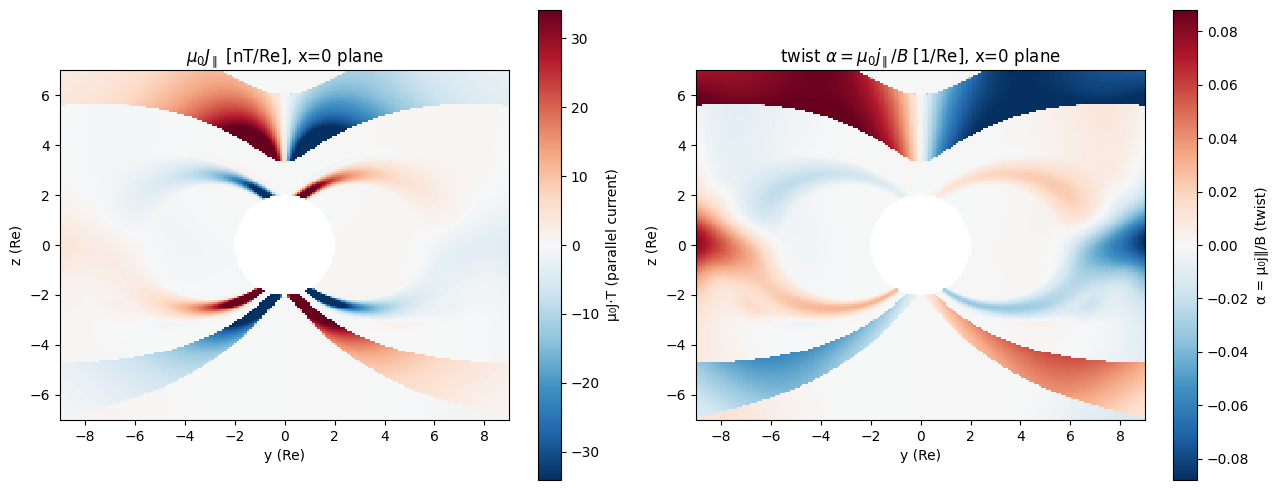

In [7]:
from mageometry import viz

earth = lambda x, y, z: x**2 + y**2 + z**2 < 2.0**2
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
viz.plot_geometry_map(t96, 'mu0J_T', plane='yz', extent=(-9, 9, -7, 7),
                      mask=earth, unit='Re', delta=2e-3, ax=axes[0], n=180)
axes[0].set_title(r'$\mu_0 J_\parallel$ [nT/Re], x=0 plane')
viz.plot_geometry_map(t96, 'alpha', plane='yz', extent=(-9, 9, -7, 7),
                      mask=earth, unit='Re', delta=2e-3, ax=axes[1], n=180)
axes[1].set_title(r'twist $\alpha = \mu_0 j_\parallel / B$ [1/Re], x=0 plane')
plt.tight_layout(); plt.show()

## 6. Performance and practical notes

Everything above is a handful of vectorized field evaluations per point (the current density costs one base frame, four transverse stencil frames, and five $|B|$ evaluations — about 20 field calls regardless of how many points are in the arrays):

In [8]:
import time
N = 20000
rng = np.random.default_rng(0)
rp = rng.uniform(3, 9, N); th = np.arccos(rng.uniform(-0.8, 0.8, N)); ph = rng.uniform(0, 2*np.pi, N)
xs, ys, zs = rp*np.sin(th)*np.cos(ph), rp*np.sin(th)*np.sin(ph), rp*np.cos(th)

t0 = time.perf_counter()
out = field_line_current_density(t96, xs, ys, zs, delta=2e-3)
t1 = time.perf_counter()
n_ok = np.isfinite(out['mu0J_T']).sum()
print(f"{N} points in {t1-t0:.2f} s  ({N/(t1-t0):,.0f} pts/s); finite frames at {n_ok} points")

20000 points in 7.53 s  (2,657 pts/s); finite frames at 20000 points


**Choosing $\delta$:** truncation error scales as $\delta^2$; roundoff grows as $1/\delta$. For the smooth Tsyganenko region, $\delta \sim 10^{-3}$–$10^{-2}$ Re is a good range — validate with a two-$\delta$ comparison as in the tests. For interpolated simulation data use about one grid cell, and prefer cubic interpolation: a linear interpolant's second derivatives vanish inside cells, and the twist is built from first derivatives of the *frame*, i.e. second derivatives of $\mathbf{B}$.

**Validity:** all outputs are NaN where the frame (or a transverse stencil frame) is undefined — straight-line regions, magnetic nulls, normal flips. Screen with `np.isfinite` and `field_line_frame_quality`; near the T96 Birkeland-module surfaces treat percent-level differences between stencils as model non-smoothness, not as numerical failure.

**Units:** all results are in field-unit per length-unit. For geopack fields (nT, Re), divide $\mu_0 J$ by $\mu_0 R_E$ to get A/m²: 1 nT/Re ≈ 0.125 nA/m².